# Notebook 24 - Length Formula Truth Test

This notebook answers one narrow question:

If Python has the same variables as MATLAB, does the fascicle length match?

We test the MATLAB-style TimTrack length formula directly:

    phi = alpha - betha
    faslen = thickness / sin(phi)

where alpha is the fascicle angle, betha is the superficial aponeurosis angle, and thickness is the muscle thickness between aponeuroses.

The notebook uses notebook 23 outputs for the current Python variables and MATLAB Fdat.geofeatures for the reference variables.

## Diagnostic logic

We build a full source matrix:

    alpha source:     MATLAB or Python
    betha source:     MATLAB or Python
    thickness source: MATLAB or Python

Then we recompute faslen for every combination.

The most important rows are:

- M/M/M: MATLAB alpha, MATLAB betha, MATLAB thickness. This should reproduce MATLAB faslen. If it does not, our formula is wrong.
- P/M/M: Python alpha only. This shows how much length error remains from alpha.
- M/P/M: Python betha only. This isolates superficial aponeurosis angle error.
- M/M/P: Python thickness only. This isolates aponeurosis position/thickness error.
- P/P/P: current Python formula path from notebook 23.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_geofeature_arrays,
    load_matlab_result,
)

MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
NB23_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_dohough_alpha_features_arrays.npz"
OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MATLAB_RESULT:", MATLAB_RESULT)
print("NB23_NPZ:", NB23_NPZ)
print("NB23 exists:", NB23_NPZ.exists())

PROJECT_ROOT: /Users/grosbedou/PycharmProjects/NDORMS
MATLAB_RESULT: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat
NB23_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features_arrays.npz
NB23 exists: True


In [2]:
# Load MATLAB and notebook 23 data.
if not MATLAB_RESULT.exists():
    raise FileNotFoundError(MATLAB_RESULT)
if not NB23_NPZ.exists():
    raise FileNotFoundError("Run notebook 23 first: " + str(NB23_NPZ))

mat = load_matlab_result(MATLAB_RESULT)
matlab_geo = extract_geofeature_arrays(mat)
py23 = np.load(NB23_NPZ)

n = min(len(matlab_geo["faslen_px"]), len(py23["fascicle_angle_deg"]))
print("Aligned frame count:", n)
print("MATLAB geofeature frames:", len(matlab_geo["faslen_px"]))
print("Notebook 23 frames:", len(py23["fascicle_angle_deg"]))

Aligned frame count: 2666
MATLAB geofeature frames: 2666
Notebook 23 frames: 2667


In [3]:
def sin_deg(x):
    return np.sin(np.deg2rad(x))


def cos_deg(x):
    return np.cos(np.deg2rad(x))


def faslen_from_phi(thickness_px, phi_deg, min_abs_sin=1e-12):
    thickness_px = np.asarray(thickness_px, dtype=float)
    phi_deg = np.asarray(phi_deg, dtype=float)
    denom = sin_deg(phi_deg)
    out = np.full(np.broadcast(thickness_px, phi_deg).shape, np.nan, dtype=float)
    valid = np.isfinite(thickness_px) & np.isfinite(denom) & (np.abs(denom) > min_abs_sin)
    out[valid] = thickness_px[valid] / denom[valid]
    return out


def faslen_from_components(alpha_deg, betha_deg, thickness_px):
    return faslen_from_phi(thickness_px, np.asarray(alpha_deg, dtype=float) - np.asarray(betha_deg, dtype=float))


def metric_row(name, reference, estimate):
    row = {"comparison": name}
    row.update(compute_metrics(reference, estimate))
    return row


def display_metric_frame(rows, sort_by=None):
    df = pd.DataFrame(rows)
    if sort_by is not None:
        df = df.sort_values(sort_by).reset_index(drop=True)
    display(df)
    return df


def y_at_x_for_lines(lines, x):
    lines = np.asarray(lines, dtype=float)
    x1 = lines[:, 0]
    y1 = lines[:, 1]
    x2 = lines[:, 2]
    y2 = lines[:, 3]
    denom = x2 - x1
    out = np.full(lines.shape[0], np.nan, dtype=float)
    valid = np.isfinite(denom) & (np.abs(denom) > 1e-12)
    slope = np.full(lines.shape[0], np.nan, dtype=float)
    slope[valid] = (y2[valid] - y1[valid]) / denom[valid]
    out[valid] = y1[valid] + slope[valid] * (x - x1[valid])
    return out


def line_angle_deg(lines):
    lines = np.asarray(lines, dtype=float)
    dx = lines[:, 2] - lines[:, 0]
    dy = lines[:, 3] - lines[:, 1]
    angle = np.degrees(np.arctan2(-dy, dx))
    angle = np.mod(angle, 180.0)
    angle[angle >= 90.0] -= 180.0
    return angle

In [4]:
# Reference MATLAB variables.
m_alpha = np.asarray(matlab_geo["alpha_deg"], dtype=float)[:n]
m_betha = np.asarray(matlab_geo["super_apo_angle_deg"], dtype=float)[:n]
m_gamma = np.asarray(matlab_geo["deep_apo_angle_deg"], dtype=float)[:n]
m_phi = np.asarray(matlab_geo["phi_deg"], dtype=float)[:n]
m_thickness = np.asarray(matlab_geo["muscle_thickness_px"], dtype=float)[:n]
m_faslen = np.asarray(matlab_geo["faslen_px"], dtype=float)[:n]

# Notebook 23 Python variables.
p_alpha = np.asarray(py23["fascicle_angle_deg"], dtype=float)[:n]
p_betha = np.asarray(py23["super_apo_angle_deg"], dtype=float)[:n]
p_gamma = np.asarray(py23["deep_apo_angle_deg"], dtype=float)[:n]
p_phi = np.asarray(py23["pennation_angle_deg"], dtype=float)[:n]
p_thickness = np.asarray(py23["muscle_thickness_px"], dtype=float)[:n]
p_faslen_formula_saved = np.asarray(py23["matlab_formula_fascicle_length_px"], dtype=float)[:n]
p_faslen_selected_segment = np.asarray(py23["fascicle_length_px"], dtype=float)[:n]

p_sup_lines = np.asarray(py23["sup_apo_lines"], dtype=float)[:n]
p_deep_lines = np.asarray(py23["deep_apo_lines"], dtype=float)[:n]

print("MATLAB faslen mean:", np.nanmean(m_faslen))
print("Python formula faslen mean:", np.nanmean(p_faslen_formula_saved))
print("Python selected-segment faslen mean:", np.nanmean(p_faslen_selected_segment))

MATLAB faslen mean: 616.5837632456745
Python formula faslen mean: 556.6955856014174
Python selected-segment faslen mean: 762.6221487584726


## 1. First truth check: is the formula correct?

This is the most important sanity check.

If this row is not nearly zero error, then we should stop and debug the formula itself:

    MATLAB thickness / sin(MATLAB saved phi)

This should reconstruct MATLAB geofeatures.faslen.

In [5]:
m_faslen_from_saved_phi = faslen_from_phi(m_thickness, m_phi)
m_faslen_from_alpha_betha = faslen_from_components(m_alpha, m_betha, m_thickness)
p_faslen_formula_recomputed = faslen_from_components(p_alpha, p_betha, p_thickness)

formula_check = display_metric_frame([
    metric_row("MATLAB thickness / sin(MATLAB saved phi)", m_faslen, m_faslen_from_saved_phi),
    metric_row("MATLAB thickness / sin(MATLAB alpha - betha)", m_faslen, m_faslen_from_alpha_betha),
    metric_row("notebook23 saved formula vs recomputed P/P/P", p_faslen_formula_saved, p_faslen_formula_recomputed),
])

formula_check.to_csv(OUT_DIR / "notebook24_formula_check_metrics.csv", index=False)
print("Saved:", OUT_DIR / "notebook24_formula_check_metrics.csv")

,comparison,n,bias,mae,rmse,corr
0,MATLAB thickness / sin(MATLAB saved phi),2666,1.477588e-14,1.477588e-14,4.250979e-14,1.0
1,MATLAB thickness / sin(MATLAB alpha - betha),2666,1.477588e-14,1.477588e-14,4.250979e-14,1.0
2,notebook23 saved formula vs recomputed P/P/P,2666,-3.805248e-06,2.347856e-05,2.932881e-05,1.0


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook24_formula_check_metrics.csv


## 2. Full truth matrix

Now we swap one variable source at a time.

The source labels mean:

    M = MATLAB
    P = Python notebook 23

For example, alpha=P, betha=M, thickness=M means only alpha comes from Python; aponeurosis angle and thickness are still MATLAB.

In [6]:
sources = {
    "M": {
        "alpha": m_alpha,
        "betha": m_betha,
        "thickness": m_thickness,
    },
    "P": {
        "alpha": p_alpha,
        "betha": p_betha,
        "thickness": p_thickness,
    },
}

truth_arrays = {}
truth_rows = []
for alpha_src in ["M", "P"]:
    for betha_src in ["M", "P"]:
        for thickness_src in ["M", "P"]:
            alpha = sources[alpha_src]["alpha"]
            betha = sources[betha_src]["betha"]
            thickness = sources[thickness_src]["thickness"]
            phi = alpha - betha
            faslen = faslen_from_phi(thickness, phi)
            key = f"alpha={alpha_src}, betha={betha_src}, thickness={thickness_src}"
            truth_arrays[key] = faslen
            row = metric_row(key, m_faslen, faslen)
            row.update({
                "alpha_src": alpha_src,
                "betha_src": betha_src,
                "thickness_src": thickness_src,
                "phi_mean_deg": float(np.nanmean(phi)),
                "faslen_mean_px": float(np.nanmean(faslen)),
            })
            truth_rows.append(row)

truth_matrix = display_metric_frame(truth_rows, sort_by="mae")
truth_matrix.to_csv(OUT_DIR / "notebook24_length_truth_matrix.csv", index=False)
print("Saved:", OUT_DIR / "notebook24_length_truth_matrix.csv")

,comparison,n,bias,mae,rmse,corr,alpha_src,betha_src,thickness_src,phi_mean_deg,faslen_mean_px
0,"alpha=M, betha=M, thickness=M",2666,1.477588e-14,1.477588e-14,4.250979e-14,1.000000,M,M,M,26.694068,616.583763
1,"alpha=M, betha=P, thickness=M",2666,9.017074e+00,1.054779e+01,1.423396e+01,0.995868,M,P,M,26.282272,625.600837
2,"alpha=M, betha=P, thickness=P",2666,-5.184683e+00,1.337325e+01,1.830462e+01,0.993645,M,P,P,26.282272,611.399081
3,"alpha=M, betha=M, thickness=P",2666,-1.388891e+01,1.558034e+01,2.212042e+01,0.993178,M,M,P,26.694068,602.694856
4,"alpha=P, betha=P, thickness=M",2666,-4.660734e+01,5.378216e+01,8.149136e+01,0.833799,P,P,M,28.601665,569.976421
5,"alpha=P, betha=M, thickness=M",2666,-5.401097e+01,5.703795e+01,8.470156e+01,0.845229,P,M,M,29.013460,562.572796
6,"alpha=P, betha=P, thickness=P",2666,-5.988818e+01,6.243980e+01,8.769062e+01,0.843224,P,P,P,28.601665,556.695582
7,"alpha=P, betha=M, thickness=P",2666,-6.702662e+01,6.817837e+01,9.207980e+01,0.848515,P,M,P,29.013460,549.557144


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook24_length_truth_matrix.csv


In [7]:
# A small single-variable view is easier to read.
single_variable_rows = []
for key in [
    "alpha=M, betha=M, thickness=M",
    "alpha=P, betha=M, thickness=M",
    "alpha=M, betha=P, thickness=M",
    "alpha=M, betha=M, thickness=P",
    "alpha=P, betha=P, thickness=P",
]:
    single_variable_rows.append(metric_row(key, m_faslen, truth_arrays[key]))

single_variable = display_metric_frame(single_variable_rows)
single_variable.to_csv(OUT_DIR / "notebook24_single_variable_length_metrics.csv", index=False)
print("Saved:", OUT_DIR / "notebook24_single_variable_length_metrics.csv")

,comparison,n,bias,mae,rmse,corr
0,"alpha=M, betha=M, thickness=M",2666,1.477588e-14,1.477588e-14,4.250979e-14,1.000000
1,"alpha=P, betha=M, thickness=M",2666,-5.401097e+01,5.703795e+01,8.470156e+01,0.845229
2,"alpha=M, betha=P, thickness=M",2666,9.017074e+00,1.054779e+01,1.423396e+01,0.995868
3,"alpha=M, betha=M, thickness=P",2666,-1.388891e+01,1.558034e+01,2.212042e+01,0.993178
4,"alpha=P, betha=P, thickness=P",2666,-5.988818e+01,6.243980e+01,8.769062e+01,0.843224


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook24_single_variable_length_metrics.csv


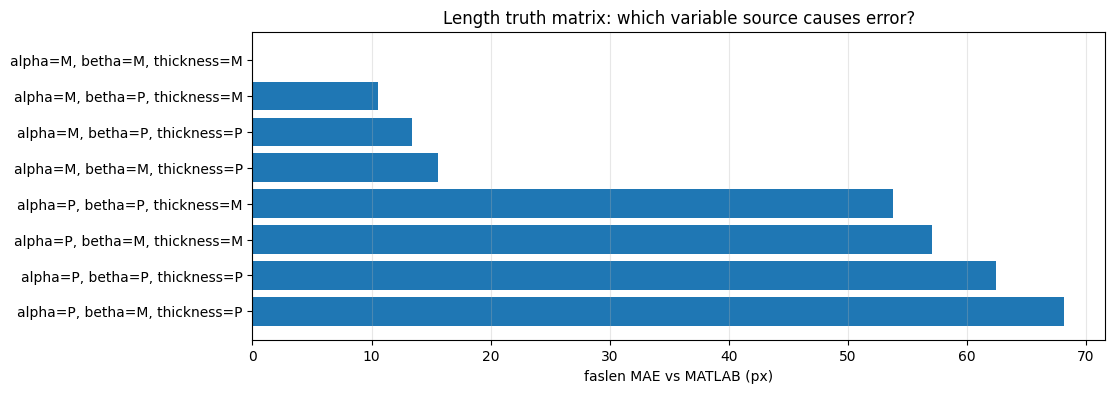

In [8]:
plt.figure(figsize=(11, 4))
plot_df = truth_matrix.sort_values("mae", ascending=True)
plt.barh(plot_df["comparison"], plot_df["mae"])
plt.xlabel("faslen MAE vs MATLAB (px)")
plt.title("Length truth matrix: which variable source causes error?")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)
plt.show()

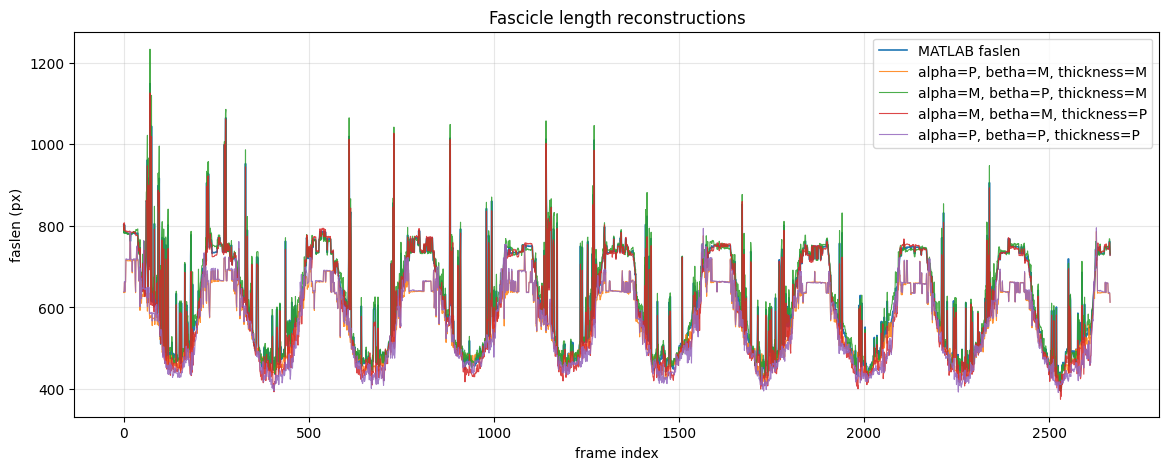

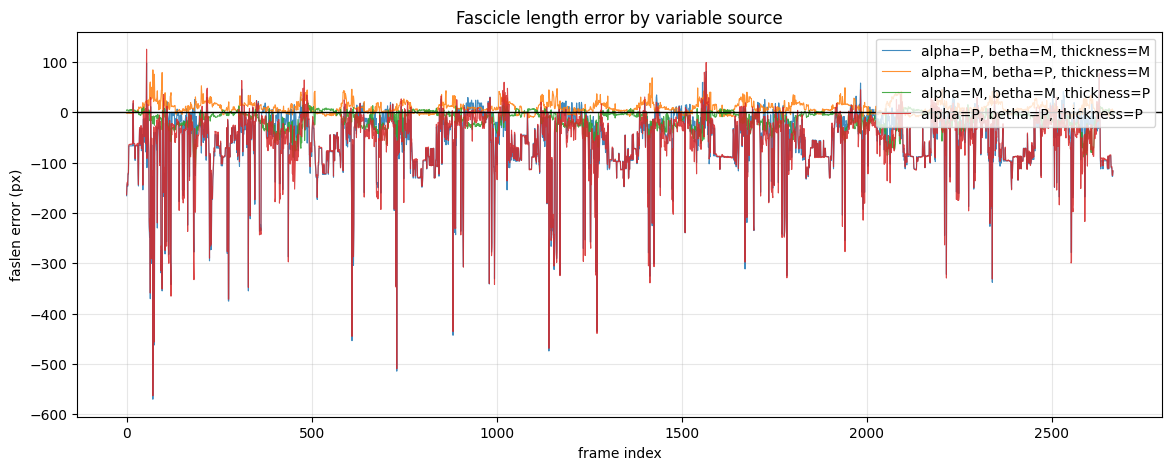

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(m_faslen, label="MATLAB faslen", linewidth=1.2)
for key in [
    "alpha=P, betha=M, thickness=M",
    "alpha=M, betha=P, thickness=M",
    "alpha=M, betha=M, thickness=P",
    "alpha=P, betha=P, thickness=P",
]:
    plt.plot(truth_arrays[key], label=key, linewidth=0.8, alpha=0.85)
plt.ylabel("faslen (px)")
plt.xlabel("frame index")
plt.title("Fascicle length reconstructions")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
for key in [
    "alpha=P, betha=M, thickness=M",
    "alpha=M, betha=P, thickness=M",
    "alpha=M, betha=M, thickness=P",
    "alpha=P, betha=P, thickness=P",
]:
    plt.plot(truth_arrays[key] - m_faslen, label=key, linewidth=0.8, alpha=0.85)
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("faslen error (px)")
plt.xlabel("frame index")
plt.title("Fascicle length error by variable source")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

## 3. Component parity

The truth matrix tells us which variable matters most for length.

This section directly compares the input variables:

- alpha
- betha
- gamma
- phi
- thickness

Remember: length is sensitive because sin(phi) is in the denominator.

In [10]:
component_rows = [
    metric_row("alpha: Python vs MATLAB", m_alpha, p_alpha),
    metric_row("betha: Python vs MATLAB", m_betha, p_betha),
    metric_row("gamma: Python vs MATLAB", m_gamma, p_gamma),
    metric_row("phi: Python alpha - MATLAB betha", m_phi, p_alpha - m_betha),
    metric_row("phi: MATLAB alpha - Python betha", m_phi, m_alpha - p_betha),
    metric_row("phi: Python alpha - Python betha", m_phi, p_alpha - p_betha),
    metric_row("thickness: Python vs MATLAB", m_thickness, p_thickness),
]

component_metrics = display_metric_frame(component_rows)
component_metrics.to_csv(OUT_DIR / "notebook24_component_metrics.csv", index=False)
print("Saved:", OUT_DIR / "notebook24_component_metrics.csv")

,comparison,n,bias,mae,rmse,corr
0,alpha: Python vs MATLAB,2666,2.319392,2.526819,3.537244,0.866061
1,betha: Python vs MATLAB,2666,0.411795,0.481269,0.618567,0.374295
2,gamma: Python vs MATLAB,2666,-0.417908,0.597219,0.882162,0.206892
3,phi: Python alpha - MATLAB betha,2666,2.319392,2.526819,3.537244,0.854832
4,phi: MATLAB alpha - Python betha,2666,-0.411795,0.481269,0.618567,0.995984
5,phi: Python alpha - Python betha,2666,1.907597,2.344573,3.339665,0.846340
6,thickness: Python vs MATLAB,2666,-6.851034,7.492083,10.768290,0.836749


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook24_component_metrics.csv


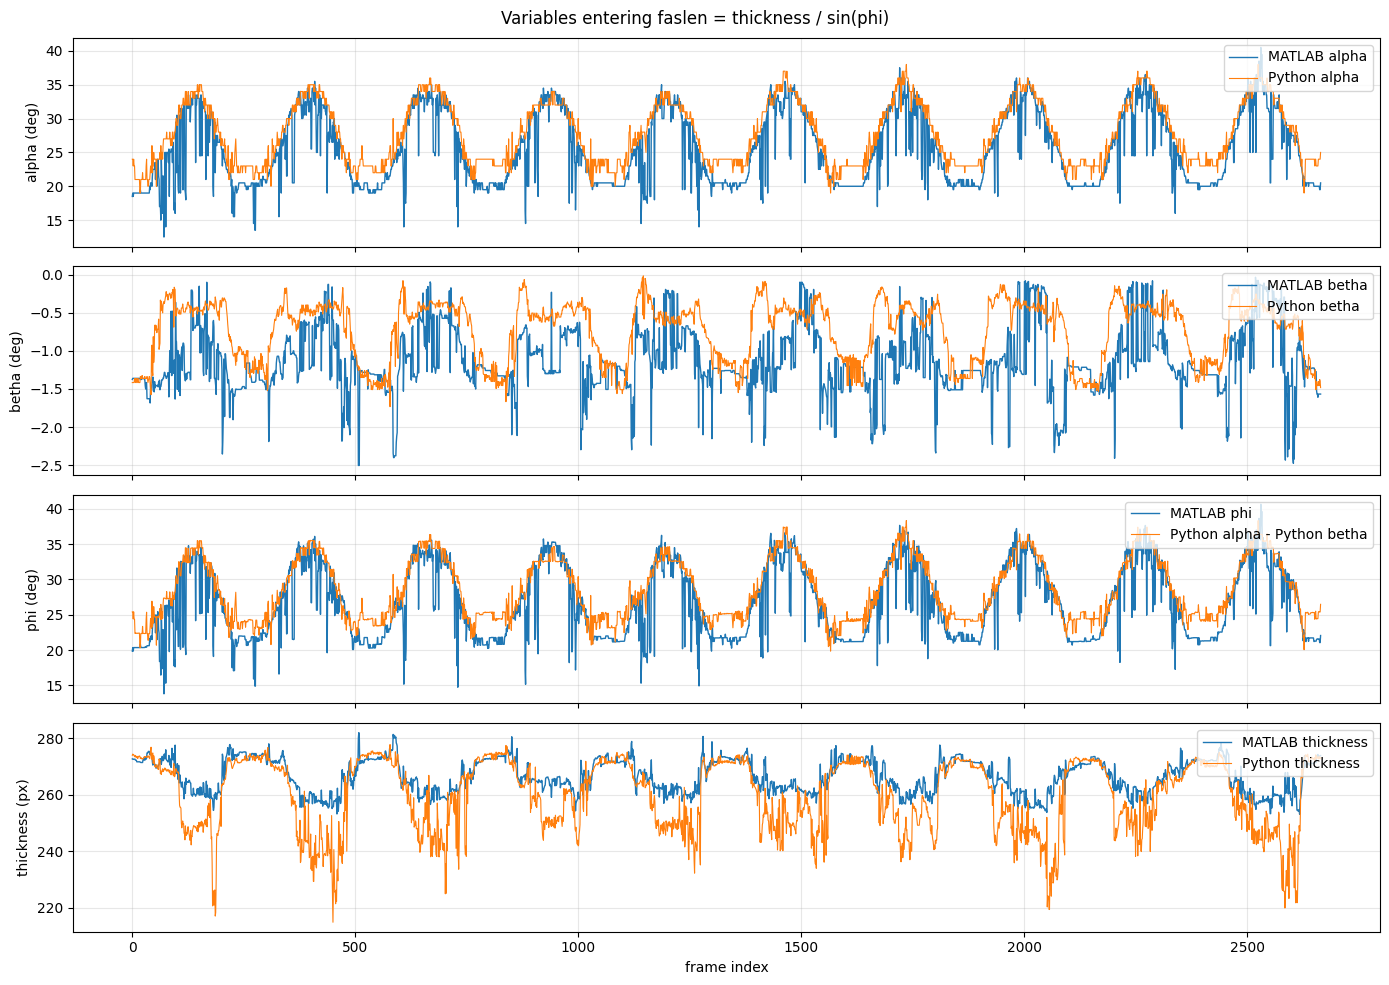

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(m_alpha, label="MATLAB alpha", linewidth=1)
axes[0].plot(p_alpha, label="Python alpha", linewidth=0.8)
axes[0].set_ylabel("alpha (deg)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(m_betha, label="MATLAB betha", linewidth=1)
axes[1].plot(p_betha, label="Python betha", linewidth=0.8)
axes[1].set_ylabel("betha (deg)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

axes[2].plot(m_phi, label="MATLAB phi", linewidth=1)
axes[2].plot(p_alpha - p_betha, label="Python alpha - Python betha", linewidth=0.8)
axes[2].set_ylabel("phi (deg)")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(m_thickness, label="MATLAB thickness", linewidth=1)
axes[3].plot(p_thickness, label="Python thickness", linewidth=0.8)
axes[3].set_ylabel("thickness (px)")
axes[3].set_xlabel("frame index")
axes[3].legend(loc="upper right")
axes[3].grid(True, alpha=0.3)

fig.suptitle("Variables entering faslen = thickness / sin(phi)")
plt.tight_layout()
plt.show()

In [12]:
# Sensitivity: how much length changes for small phi/thickness errors.
# d(thickness / sin(phi)) / d(phi_deg) = -thickness * cos(phi) / sin(phi)^2 * pi/180
valid = np.isfinite(m_thickness) & np.isfinite(m_phi) & (np.abs(sin_deg(m_phi)) > 1e-12)
d_len_d_phi_deg = -m_thickness[valid] * cos_deg(m_phi[valid]) / (sin_deg(m_phi[valid]) ** 2) * (np.pi / 180.0)
d_len_d_thickness = 1.0 / sin_deg(m_phi[valid])

sensitivity = pd.DataFrame([
    {
        "quantity": "abs d(faslen)/d(phi_deg)",
        "median": float(np.nanmedian(np.abs(d_len_d_phi_deg))),
        "p95": float(np.nanpercentile(np.abs(d_len_d_phi_deg), 95)),
        "unit": "px per deg",
    },
    {
        "quantity": "d(faslen)/d(thickness_px)",
        "median": float(np.nanmedian(np.abs(d_len_d_thickness))),
        "p95": float(np.nanpercentile(np.abs(d_len_d_thickness), 95)),
        "unit": "px per px",
    },
])

display(sensitivity)
sensitivity.to_csv(OUT_DIR / "notebook24_length_sensitivity.csv", index=False)
print("Saved:", OUT_DIR / "notebook24_length_sensitivity.csv")

,quantity,median,p95,unit
0,abs d(faslen)/d(phi_deg),21.799118,35.734919,px per deg
1,d(faslen)/d(thickness_px),2.286217,2.843461,px per px


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook24_length_sensitivity.csv


## 4. Is the thickness evaluation x-position important?

Notebook 23 currently computes Python thickness at x_eval = 20.

This section recomputes Python thickness from the saved Python aponeurosis lines over many x-positions. If the best x-position dramatically reduces length error, then the next notebook should focus on matching MATLAB's exact super_pos and deep_pos geometry.

In [13]:
all_x = np.concatenate([
    p_sup_lines[:, [0, 2]].reshape(-1),
    p_deep_lines[:, [0, 2]].reshape(-1),
])
all_x = all_x[np.isfinite(all_x)]
x_min = max(0.0, float(np.nanpercentile(all_x, 1)))
x_max = float(np.nanpercentile(all_x, 99))
if x_max <= x_min:
    x_min, x_max = 0.0, float(np.nanmax(all_x))

x_grid = np.linspace(x_min, x_max, 121)
sweep_rows = []
for x_eval in x_grid:
    super_y = y_at_x_for_lines(p_sup_lines, x_eval)
    deep_y = y_at_x_for_lines(p_deep_lines, x_eval)
    thickness_x = (deep_y - super_y) * cos_deg(p_betha)
    faslen_x_ppp = faslen_from_phi(thickness_x, p_alpha - p_betha)
    faslen_x_mpp = faslen_from_phi(thickness_x, m_alpha - p_betha)
    row_ppp = metric_row("Python alpha, Python betha", m_faslen, faslen_x_ppp)
    row_mpp = metric_row("MATLAB alpha, Python betha", m_faslen, faslen_x_mpp)
    sweep_rows.append({
        "x_eval": float(x_eval),
        "ppp_mae": row_ppp["mae"],
        "ppp_bias": row_ppp["bias"],
        "mpp_mae": row_mpp["mae"],
        "mpp_bias": row_mpp["bias"],
        "mean_thickness": float(np.nanmean(thickness_x)),
    })

x_sweep = pd.DataFrame(sweep_rows)
display(x_sweep.sort_values("ppp_mae").head(10))
x_sweep.to_csv(OUT_DIR / "notebook24_x_eval_sweep.csv", index=False)
print("Saved:", OUT_DIR / "notebook24_x_eval_sweep.csv")

best_ppp = x_sweep.loc[x_sweep["ppp_mae"].idxmin()]
best_mpp = x_sweep.loc[x_sweep["mpp_mae"].idxmin()]
print("Best x for P/P/P:", dict(best_ppp))
print("Best x for M/P/P:", dict(best_mpp))

,x_eval,ppp_mae,ppp_bias,mpp_mae,mpp_bias,mean_thickness
120,704.000000,47.120105,-32.833827,24.234639,24.164472,273.067849
119,698.258333,47.131115,-33.060928,23.986322,23.918108,272.955525
118,692.516667,47.143745,-33.288029,23.738013,23.671744,272.843201
117,686.775000,47.157833,-33.515130,23.489703,23.425379,272.730877
116,681.033333,47.174960,-33.742231,23.241394,23.179015,272.618552
115,675.291667,47.193715,-33.969332,22.993146,22.932651,272.506228
114,669.550000,47.213830,-34.196433,22.745148,22.686287,272.393904
113,663.808333,47.235240,-34.423534,22.497216,22.439923,272.281580
112,658.066667,47.259089,-34.650635,22.249284,22.193559,272.169256
111,652.325000,47.284735,-34.877736,22.001395,21.947195,272.056932


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook24_x_eval_sweep.csv
Best x for P/P/P: {'x_eval': np.float64(704.0), 'ppp_mae': np.float64(47.12010544640626), 'ppp_bias': np.float64(-32.83382729117183), 'mpp_mae': np.float64(24.234638845173475), 'mpp_bias': np.float64(24.164471836963934), 'mean_thickness': np.float64(273.0678488215123)}
Best x for M/P/P: {'x_eval': np.float64(261.89166666666665), 'ppp_mae': np.float64(54.54232593694229), 'ppp_bias': np.float64(-50.32060378376688), 'mpp_mae': np.float64(10.761672575482677), 'mpp_bias': np.float64(5.194434711485099), 'mean_thickness': np.float64(264.41889263730684)}


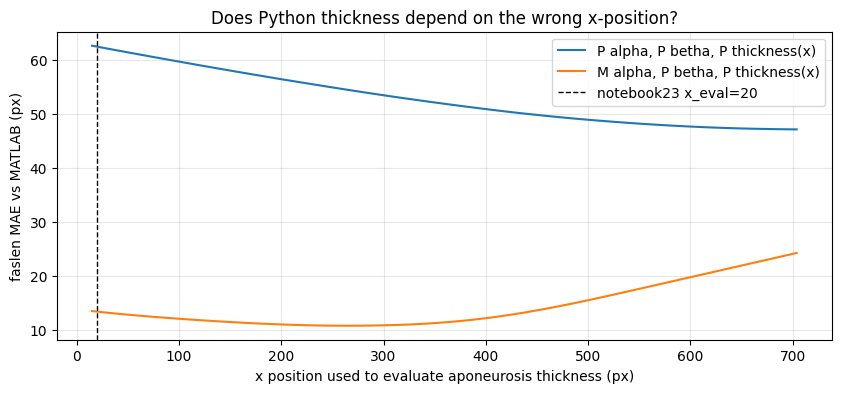

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(x_sweep["x_eval"], x_sweep["ppp_mae"], label="P alpha, P betha, P thickness(x)")
plt.plot(x_sweep["x_eval"], x_sweep["mpp_mae"], label="M alpha, P betha, P thickness(x)")
plt.axvline(20.0, color="black", linestyle="--", linewidth=1, label="notebook23 x_eval=20")
plt.xlabel("x position used to evaluate aponeurosis thickness (px)")
plt.ylabel("faslen MAE vs MATLAB (px)")
plt.title("Does Python thickness depend on the wrong x-position?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Save arrays for future notebooks without recomputing.
np.savez(
    OUT_DIR / "notebook24_length_truth_arrays.npz",
    matlab_faslen=m_faslen,
    matlab_alpha=m_alpha,
    matlab_betha=m_betha,
    matlab_phi=m_phi,
    matlab_thickness=m_thickness,
    python_alpha=p_alpha,
    python_betha=p_betha,
    python_phi=p_phi,
    python_thickness=p_thickness,
    python_formula_faslen=p_faslen_formula_saved,
    python_selected_segment_faslen=p_faslen_selected_segment,
    matlab_formula_from_saved_phi=m_faslen_from_saved_phi,
    matlab_formula_from_alpha_betha=m_faslen_from_alpha_betha,
    python_formula_recomputed=p_faslen_formula_recomputed,
    alpha_P_betha_M_thickness_M=truth_arrays["alpha=P, betha=M, thickness=M"],
    alpha_M_betha_P_thickness_M=truth_arrays["alpha=M, betha=P, thickness=M"],
    alpha_M_betha_M_thickness_P=truth_arrays["alpha=M, betha=M, thickness=P"],
    alpha_P_betha_P_thickness_P=truth_arrays["alpha=P, betha=P, thickness=P"],
)
print("Saved:", OUT_DIR / "notebook24_length_truth_arrays.npz")

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook24_length_truth_arrays.npz


## How to read the result

Use this order:

1. Check the formula row: MATLAB thickness / sin(MATLAB saved phi). If the error is nearly zero, the length formula is confirmed.
2. Check alpha=P, betha=M, thickness=M. This is the remaining length error caused by Python alpha only.
3. Check alpha=M, betha=P, thickness=M. This is the error caused by Python superficial aponeurosis angle only.
4. Check alpha=M, betha=M, thickness=P. This is the error caused by Python thickness only.
5. Check alpha=P, betha=P, thickness=P. This is the current Python formula path.

The next notebook should focus on the largest single-variable source of error.

In [16]:
summary_rows = []
for key in [
    "alpha=M, betha=M, thickness=M",
    "alpha=P, betha=M, thickness=M",
    "alpha=M, betha=P, thickness=M",
    "alpha=M, betha=M, thickness=P",
    "alpha=P, betha=P, thickness=P",
]:
    row = metric_row(key, m_faslen, truth_arrays[key])
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
display(summary)

oracle_mae = float(summary.loc[summary["comparison"] == "alpha=M, betha=M, thickness=M", "mae"].iloc[0])
alpha_only_mae = float(summary.loc[summary["comparison"] == "alpha=P, betha=M, thickness=M", "mae"].iloc[0])
betha_only_mae = float(summary.loc[summary["comparison"] == "alpha=M, betha=P, thickness=M", "mae"].iloc[0])
thickness_only_mae = float(summary.loc[summary["comparison"] == "alpha=M, betha=M, thickness=P", "mae"].iloc[0])
current_formula_mae = float(summary.loc[summary["comparison"] == "alpha=P, betha=P, thickness=P", "mae"].iloc[0])

print("Formula confirmed:", oracle_mae < 1e-6)
print(f"Alpha-only MAE:     {alpha_only_mae:.3f} px")
print(f"Betha-only MAE:     {betha_only_mae:.3f} px")
print(f"Thickness-only MAE: {thickness_only_mae:.3f} px")
print(f"Current P/P/P MAE:  {current_formula_mae:.3f} px")

single_sources = {
    "alpha": alpha_only_mae,
    "betha": betha_only_mae,
    "thickness": thickness_only_mae,
}
print("Largest single-variable source:", max(single_sources, key=single_sources.get))

,comparison,n,bias,mae,rmse,corr
0,"alpha=M, betha=M, thickness=M",2666,1.477588e-14,1.477588e-14,4.250979e-14,1.000000
1,"alpha=P, betha=M, thickness=M",2666,-5.401097e+01,5.703795e+01,8.470156e+01,0.845229
2,"alpha=M, betha=P, thickness=M",2666,9.017074e+00,1.054779e+01,1.423396e+01,0.995868
3,"alpha=M, betha=M, thickness=P",2666,-1.388891e+01,1.558034e+01,2.212042e+01,0.993178
4,"alpha=P, betha=P, thickness=P",2666,-5.988818e+01,6.243980e+01,8.769062e+01,0.843224


Formula confirmed: True
Alpha-only MAE:     57.038 px
Betha-only MAE:     10.548 px
Thickness-only MAE: 15.580 px
Current P/P/P MAE:  62.440 px
Largest single-variable source: alpha
